<a href="https://colab.research.google.com/github/ThevinduFernando2003/python-machine-learning/blob/main/MagicML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abhinand05/magic-gamma-telescope-dataset")

print("Path to dataset files:", path)

100%|██████████| 706k/706k [00:00<00:00, 112MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/abhinand05/magic-gamma-telescope-dataset/versions/1


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [17]:
import os

# List contents of the downloaded directory
files = os.listdir(path)

# Assuming there's one CSV file, find it
csv_files = [f for f in files if f.endswith('.csv')]

if csv_files:
    csv_file_name = csv_files[0]
    full_csv_path = os.path.join(path, csv_file_name)
    df = pd.read_csv(full_csv_path)

    # Define column names including 'Unnamed: 0' if it exists
    # The 'cols' variable defined later does not include 'Unnamed: 0', so let's ensure consistency.
    # For now, let's just make sure the 'class' conversion is correct and unique.

    # Apply conversion immediately after loading to ensure it's done only once and correctly
    df['class'] = (df['class'] == 'g').astype(int)
    print(df.head())
    print("\nValue counts after initial conversion:")
    print(df['class'].value_counts())
else:
    print(f"No CSV files found in the directory: {path}")

   Unnamed: 0   fLength    fWidth   fSize   fConc  fConc1     fAsym  fM3Long  \
0           0   28.7967   16.0021  2.6449  0.3918  0.1982   27.7004  22.0110   
1           1   31.6036   11.7235  2.5185  0.5303  0.3773   26.2722  23.8238   
2           2  162.0520  136.0310  4.0612  0.0374  0.0187  116.7410 -64.8580   
3           3   23.8172    9.5728  2.3385  0.6147  0.3922   27.2107  -6.4633   
4           4   75.1362   30.9205  3.1611  0.3168  0.1832   -5.5277  28.5525   

   fM3Trans   fAlpha     fDist  class  
0   -8.2027  40.0920   81.8828      1  
1   -9.9574   6.3609  205.2610      1  
2  -45.2160  76.9600  256.7880      1  
3   -7.1513  10.4490  116.7370      1  
4   21.8393   4.6480  356.4620      1  

Value counts after initial conversion:
class
1    12332
0     6688
Name: count, dtype: int64


In [6]:
cols = ["fLength", "fWidth", "fSize", "fConc", "fConc1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
#df = pd.read_csv("filename.csv", names=cols)
df.head()

,Unnamed: 0,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


In [18]:
# This cell previously contained a redundant and incorrect class conversion.
# The conversion is now handled in cell HNNKHIjyaZHg to ensure correctness and avoid errors.
# We can use this cell for other purposes, or simply leave it blank if no other operations are needed here.

In [8]:
print(df['class'].value_counts()) # Check value counts after reloading and converting

class
0    19020
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/numpy/lib/_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


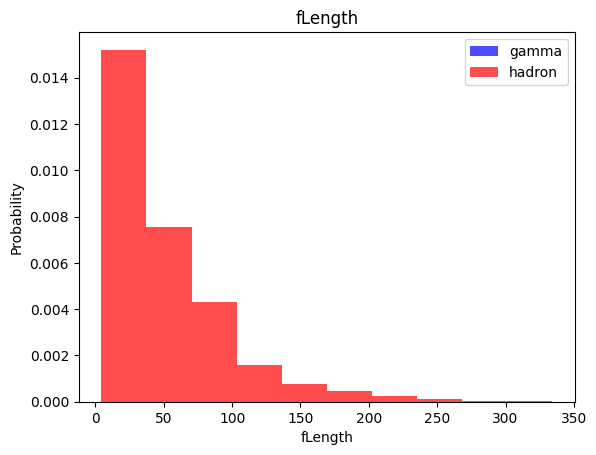

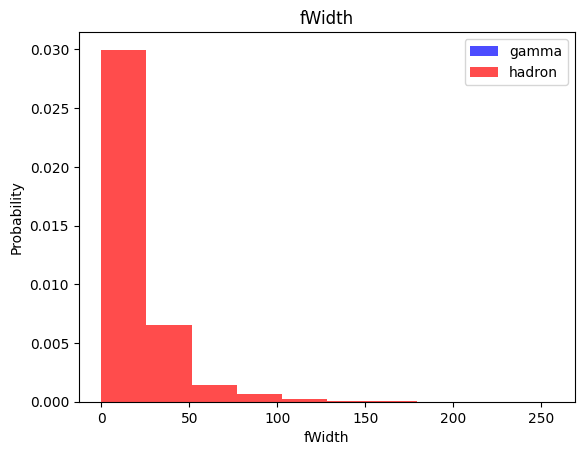

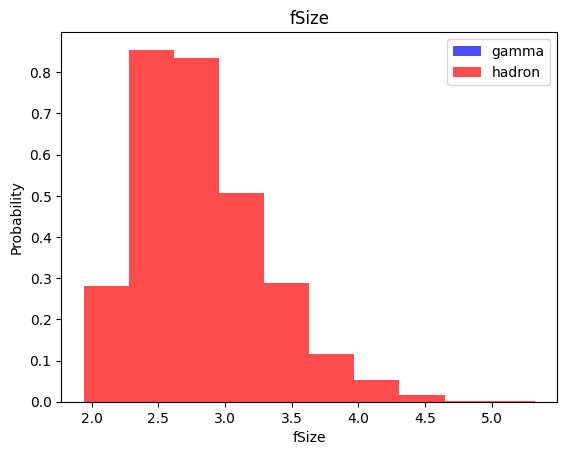

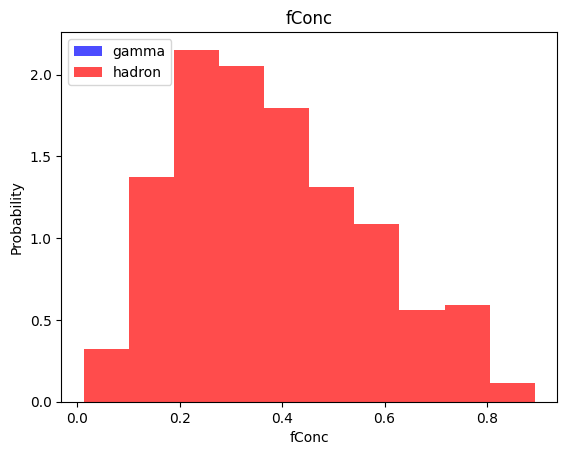

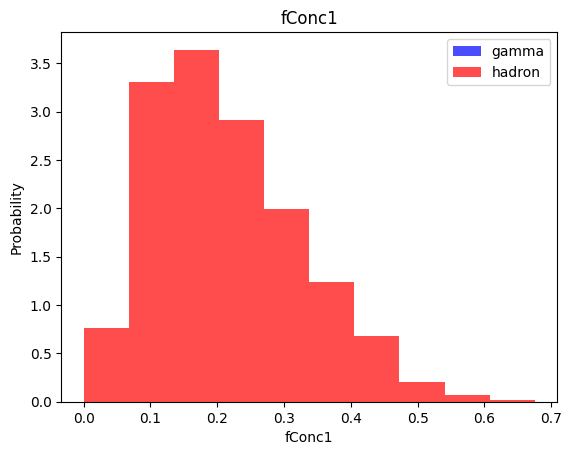

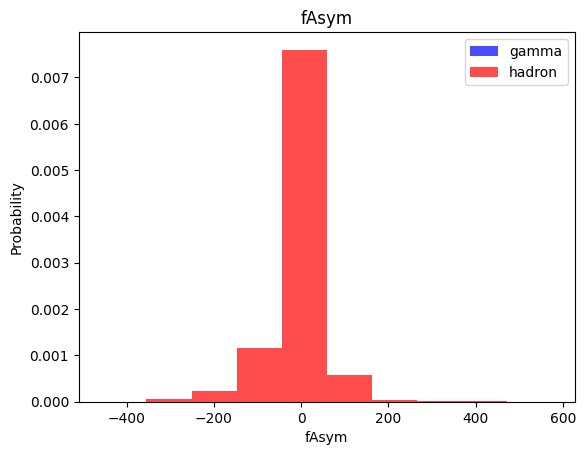

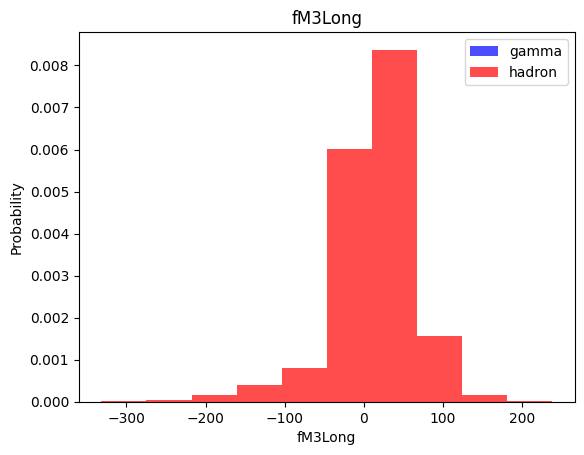

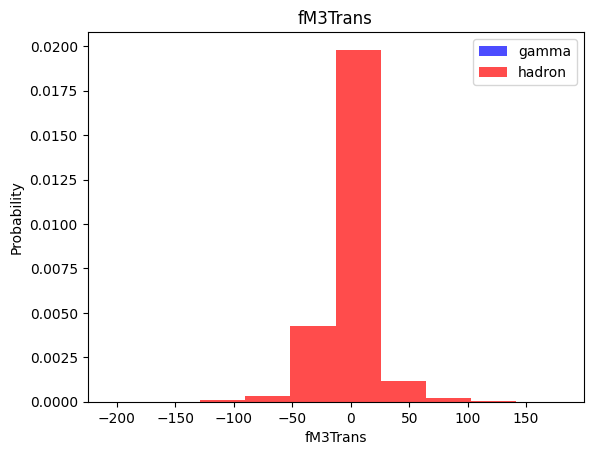

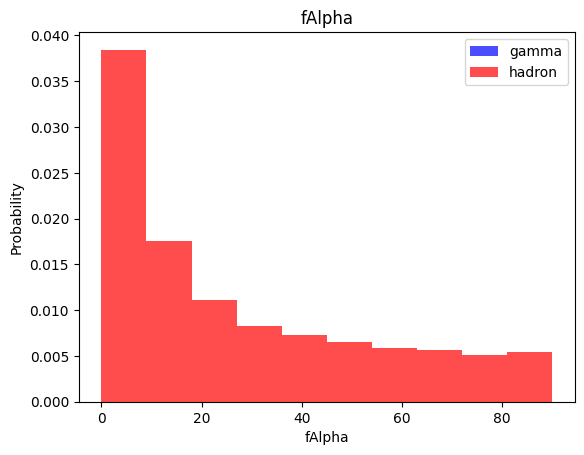

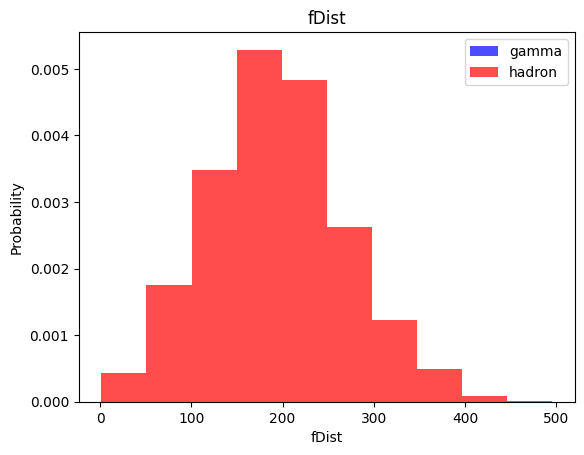

In [9]:
for label in cols[:-1]:
  plt.hist(df[df['class']==1][label], color = 'blue', label='gamma', alpha=0.7, density=True)
  plt.hist(df[df['class']==0][label], color = 'red', label='hadron', alpha=0.7, density=True)
  plt.title(label)
  plt.ylabel("Probability")
  plt.xlabel(label)
  plt.legend()
  plt.show()

Train, Validation, test datasets

In [10]:
# To inspect the original 'class' values before conversion, we'll reload the df
# and then check its unique 'class' values.

# Reload the original DataFrame to see raw 'class' values
full_csv_path = '/root/.cache/kagglehub/datasets/abhinand05/magic-gamma-telescope-dataset/versions/1/telescope_data.csv'
df_original = pd.read_csv(full_csv_path)

print("Unique values in original 'class' column:")
print(df_original['class'].unique())


Unique values in original 'class' column:
['g' 'h']


In [11]:
# To inspect the original 'class' values before conversion, we'll reload the df
# and then check its unique 'class' values.

# Reload the original DataFrame to see raw 'class' values
full_csv_path = '/root/.cache/kagglehub/datasets/abhinand05/magic-gamma-telescope-dataset/versions/1/telescope_data.csv'
df_original = pd.read_csv(full_csv_path)

print("Unique values in original 'class' column:")
print(df_original['class'].unique())


Unique values in original 'class' column:
['g' 'h']


In [12]:
num_class_1 = df[df['class'] == 1].shape[0]
print(f"Number of rows with class = 1: {num_class_1}")

Number of rows with class = 1: 0


In [13]:
num_class_0 = df[df['class'] == 0].shape[0]
print(f"Number of rows with class = 0: {num_class_0}")

Number of rows with class = 0: 19020


In [21]:
# Split the data into training, validation, and test sets, ensuring stratification
# This helps maintain the proportion of classes in each subset.

# First split: 60% for training, 40% for a temporary set (validation + test)
train, temp_df = train_test_split(df, test_size=0.4, random_state=42, stratify=df['class'])

# Second split: From the temporary set, 50% for validation and 50% for test
# This results in 20% of the original data for validation and 20% for test.
valid, test = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['class'])

print("Train class distribution:")
print(train['class'].value_counts())
print("\nValid class distribution:")
print(valid['class'].value_counts())
print("\nTest class distribution:")
print(test['class'].value_counts())

Train class distribution:
class
1    7399
0    4013
Name: count, dtype: int64

Valid class distribution:
class
1    2467
0    1337
Name: count, dtype: int64

Test class distribution:
class
1    2466
0    1338
Name: count, dtype: int64


In [15]:
def scale_dataset(dataframe,oversample=False):
  X = dataframe[cols[:-1]].values #x- axis
  y = dataframe[cols[-1]].values #y-axis or results

  scaler = StandardScaler()
  X = scaler.fit_transform(X)

  if oversample:
    ros = RandomOverSampler()
    X, y = ros.fit_resample(X, y)

  data = np.hstack((X, np.reshape(y, (-1, 1))))

  return data, X, y

In [22]:
train_scaled, X_train, y_train = scale_dataset(train, oversample=True)
valid_scaled, X_valid, y_valid = scale_dataset(valid, oversample=False)
test_scaled, X_test, y_test = scale_dataset(test, oversample=False)

In [23]:
train

,Unnamed: 0,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
15614,15614,19.3169,6.0723,2.4571,0.8517,0.5951,14.7595,18.1737,-4.8309,45.3267,116.5540,0
7851,7851,33.6473,16.4682,2.5165,0.3805,0.1963,35.1490,-16.0461,-8.5730,30.9140,64.9293,1
13506,13506,95.2551,29.3494,3.5036,0.1622,0.0860,67.6239,84.4564,-26.3234,11.6527,134.1558,0
10847,10847,40.3395,26.5826,3.2501,0.2064,0.1082,20.6936,27.6040,18.2863,9.6010,148.6510,1
18476,18476,185.0110,102.9840,4.5313,0.0521,0.0278,-215.7800,-137.8800,-48.9858,64.2090,283.3700,0
...,...,...,...,...,...,...,...,...,...,...,...,...
15406,15406,41.2800,26.0503,3.3525,0.1952,0.0933,18.5883,-46.5309,-15.1777,66.6318,98.1673,0
14848,14848,107.2150,95.9015,2.9410,0.3517,0.2159,84.1833,122.8310,93.5248,85.4025,149.5740,0
14113,14113,47.3963,10.9703,2.9186,0.3643,0.1852,41.0561,17.1909,5.0734,39.5930,38.8736,0
4386,4386,30.6824,12.6495,2.4654,0.5171,0.3373,22.4071,23.3827,-8.9681,9.7889,157.3770,1


In [24]:
print(len(y_train)) #gamma
print(len(X_train))

14798
14798


KNN

In [25]:
from sklearn.neighbors import KNeighborsClassifier

In [26]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [27]:
y_pred = knn_model.predict(X_test)

In [28]:
print(classification_report(y_test, y_pred))

#support : no of actual occurences of each class
#Precision: The ability of the classifier not to label as positive a sample that is negative= true positive / all positives
#Recall : Ability of the classifier to find all the positive samples : True positives / All real positives
#F1 score : mean of precision and recall
#accuracy: Correctly predictions of the instances
#Macro Avg: average of each metric independentky for each class
#Weighted avg: average of each metric by the instances


              precision    recall  f1-score   support

           0       0.73      0.72      0.72      1338
           1       0.85      0.86      0.85      2466

    accuracy                           0.81      3804
   macro avg       0.79      0.79      0.79      3804
weighted avg       0.81      0.81      0.81      3804



Naive bayes

In [29]:
from sklearn.naive_bayes import GaussianNB

In [30]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

In [31]:
y_pred = nb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.42      0.52      1338
           1       0.74      0.89      0.81      2466

    accuracy                           0.72      3804
   macro avg       0.71      0.65      0.66      3804
weighted avg       0.72      0.72      0.70      3804



Logistic regression

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, y_train)

In [34]:
y_pred = lg_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.71      0.69      1338
           1       0.84      0.81      0.83      2466

    accuracy                           0.78      3804
   macro avg       0.76      0.76      0.76      3804
weighted avg       0.78      0.78      0.78      3804



Support Vector Machines

In [35]:
from sklearn.svm import SVC

In [36]:
svc_model = SVC()
svc_model = svc_model.fit(X_train, y_train)

In [37]:
y_pred = svc_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.79      0.79      1338
           1       0.89      0.89      0.89      2466

    accuracy                           0.86      3804
   macro avg       0.84      0.84      0.84      3804
weighted avg       0.86      0.86      0.86      3804



Neural Networks